In [27]:
import numpy as np

# Hours studied
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
# Outcome: 0 = failed, 1 = passed
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [28]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [29]:
# Binary cross-entropy loss
def binary_cross_entropy(y_true, y_pred):
    return -np.mean((y_true * np.log(y_pred)) + ((1-y_true) * np.log(1-y_pred)))

In [59]:
# Initialize parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.1
epochs = 5000
n = len(X)

for epoch in range(epochs):
    # 1. Linear combination
    z = w * X + b

    # 2. Apply sigmoid to get probabilities
    y_pred = sigmoid(z)

    # 3. Compute error
    error = y_pred - y

    # 4. Compute gradients (same form as linear regression!)
    dw = (1/n) * np.sum(error * X)
    db = (1/n) * np.sum(error)

    # 5. Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # 6. Print progress every 500 epochs
    if epoch % 500 == 0:
        loss = binary_cross_entropy(y, y_pred)
        print(f"Epoch: {epoch}, w = {w:.4f}, b = {b:.4f}, loss = {loss:.4f}")
print(f"Final w = {w:.4f}, b = {b:.4f}")

Epoch: 0, w = 0.1250, b = 0.0000, loss = 0.6931
Epoch: 500, w = 0.8021, b = -4.0596, loss = 0.2050
Epoch: 1000, w = 1.0804, b = -5.6666, loss = 0.1505
Epoch: 1500, w = 1.2702, b = -6.7473, loss = 0.1262
Epoch: 2000, w = 1.4191, b = -7.5886, loss = 0.1116
Epoch: 2500, w = 1.5437, b = -8.2899, loss = 0.1014
Epoch: 3000, w = 1.6522, b = -8.8983, loss = 0.0937
Epoch: 3500, w = 1.7490, b = -9.4397, loss = 0.0877
Epoch: 4000, w = 1.8369, b = -9.9303, loss = 0.0827
Epoch: 4500, w = 1.9177, b = -10.3809, loss = 0.0785
Final w = 1.9926, b = -10.7981


In [60]:
# Predictions
print("\n--- Predictions ---")
test_hours = [2, 4.5, 7, 9]
for h in test_hours:
    prob = sigmoid(w * h + b)
    pred = 1 if prob > 0.5 else 0
    label = "PASS" if pred == 1 else "FAIL"
    print(f"Studied {h} hrs → P(pass) = {prob:.4f} → Predicted: {label}")


--- Predictions ---
Studied 2 hrs → P(pass) = 0.0011 → Predicted: FAIL
Studied 4.5 hrs → P(pass) = 0.1381 → Predicted: FAIL
Studied 7 hrs → P(pass) = 0.9589 → Predicted: PASS
Studied 9 hrs → P(pass) = 0.9992 → Predicted: PASS


In [61]:
# Training accuracy
train_probs = sigmoid(w * X + b)
train_preds = (train_probs > 0.5).astype(int)
accuracy = np.mean(train_preds == y)
print(f"\nTraining accuracy: {accuracy*100:.2f}%")


Training accuracy: 100.00%


In [62]:
# Decision boundary (where probability = 0.5, meaning z = 0)
# z = w*x + b = 0 → x = -b/w
decision_boundary = -b/w
print(f"Decision Boundary: {decision_boundary} hours")

Decision Boundary: 5.419103276698012 hours


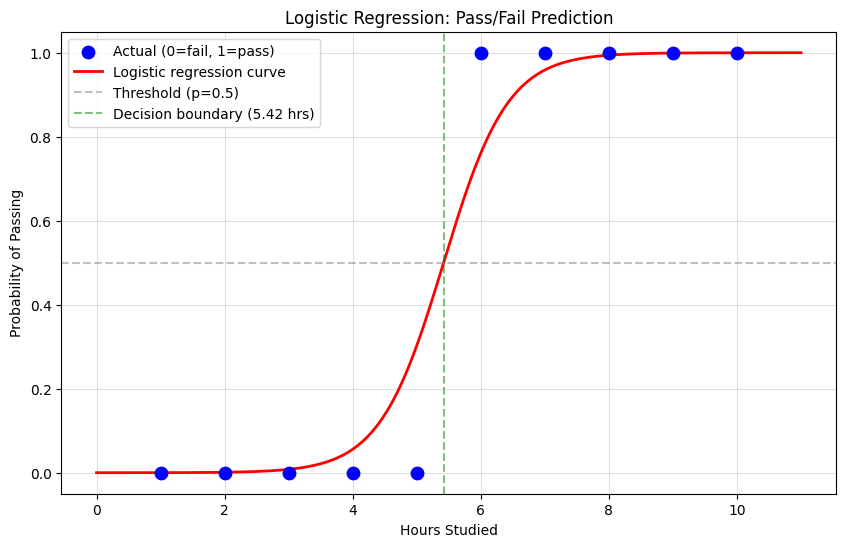

In [63]:
# Visualize
plt.figure(figsize=(10, 6))

# Actual data points
plt.scatter(X, y, color='blue', s=80, label='Actual (0=fail, 1=pass)', zorder=3)

# Smooth sigmoid curve
X_smooth = np.linspace(0, 11, 200)
y_smooth = sigmoid(w * X_smooth + b)
plt.plot(X_smooth, y_smooth, color='red', linewidth=2, label='Logistic regression curve')

# Decision threshold
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold (p=0.5)')
plt.axvline(x=decision_boundary, color='green', linestyle='--', alpha=0.5,
            label=f'Decision boundary ({decision_boundary:.2f} hrs)')

plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression: Pass/Fail Prediction')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()